In [3]:
# Import opendataset libraries
import opendatasets as od

In [4]:
# Download the Dataset
od.download('https://www.kaggle.com/datasets/kausthubkannan/5-flower-types-classification-dataset')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Ronok Rahman
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kausthubkannan/5-flower-types-classification-dataset


100%|██████████| 242M/242M [00:07<00:00, 33.1MB/s]


In [12]:
# Import Required Libraries
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense,Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
import matplotlib.pyplot as plt


In [10]:
# Load the dataset and split into trainset
train_ds = keras.utils.image_dataset_from_directory(
    "/content/5_flowers/flower_images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 4999 files belonging to 5 classes.
Using 4000 files for training.


In [11]:
# Load the dataset and split into validation set
val_ds = keras.utils.image_dataset_from_directory(
    "/content/5_flowers/flower_images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 4999 files belonging to 5 classes.
Using 999 files for validation.


In [18]:
# Normalize the dataset from [0.255] to [0,1]
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [14]:
# Build the AlexNET model

# Creates Sequential Layer
model = Sequential()

# Layer 1
model.add(Conv2D(filters=96,
                 kernel_size=(11,11),
                 strides=(4,4),
                 padding='valid',
                 activation='relu',
                 input_shape=(224,224,3)))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(3,3),
                       strides=(2,2)))

# Layer 2
model.add(Conv2D(filters=256,
                 kernel_size=(5,5),
                 padding='same',
                 activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(3,3),
                       strides=(2,2)))

# Layer 3
model.add(Conv2D(filters=384,
                 kernel_size=(3,3),
                 padding='same',
                 activation='relu'))

# Layer 4
model.add(Conv2D(filters=384,
                 kernel_size=(3,3),
                 padding='same',
                 activation='relu'))

# Layer 5
model.add(Conv2D(filters=256,
                 kernel_size=(3,3),
                 padding='same',
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(3,3),
                       strides=(2,2)))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Check the structure of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,305,297 (535.22 MB)

 Trainable params: 46,768,197 (178.41 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 93,536,396 (356.81 MB)

In [20]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.1985 - loss: 1.6095 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.1908 - loss: 1.6095 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.1988 - loss: 1.6096 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.2000 - loss: 1.6093 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.2040 - loss: 1.6097 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.1965 - loss: 1.6095 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.1922 - loss: 1.6096 - val_accuracy: 0.1902 - val_loss: 1.6100
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.2033 - loss: 1.6094 - 

In [24]:
# Evaluate the Model
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1902 - loss: 1.6100
Validation Loss : 1.6100273132324219
Validation Accuracy : 0.19019019603729248


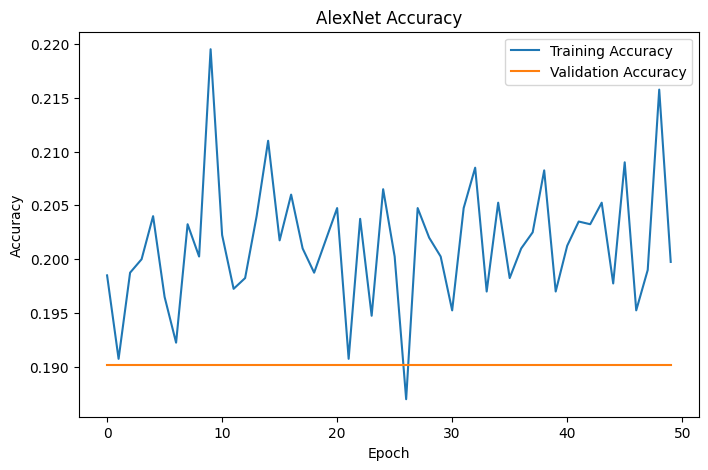

In [26]:
# Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("AlexNet Accuracy")
plt.legend()

plt.show()

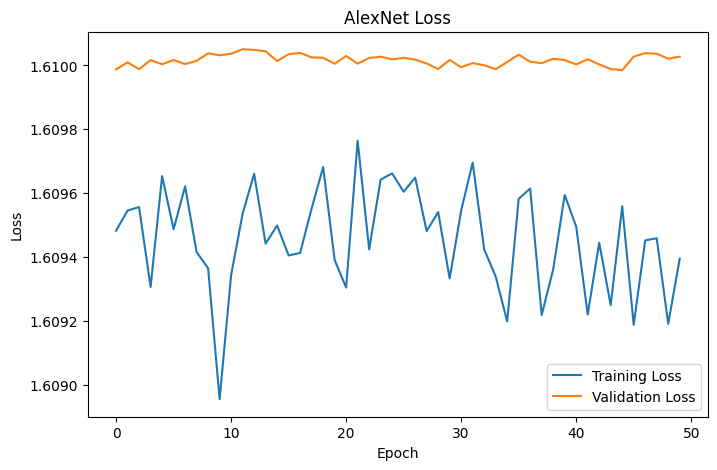

In [27]:
# Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AlexNet Loss")
plt.legend()

plt.show()